In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 데이터 불러오기

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/한경-부트캠프/강의/기타/최종 프로젝트/코드파일/data/반려견.csv')

# 데이터 확인

In [ ]:
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13572 entries, 0 to 13571
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   metadata_id_age                13572 non-null  float64
 1   metadata_id_breed              13572 non-null  object 
 2   metadata_id_sex                13572 non-null  object 
 3   neutered                       13572 non-null  int64  
 4   metadata_physical_weight       13572 non-null  float64
 5   metadata_breeding_food-amount  13572 non-null  float64
 6   metadata_medical_diseaseName   13572 non-null  object 
dtypes: float64(3), int64(1), object(3)
memory usage: 742.3+ KB


(None, (13572, 7))

In [ ]:
df.head()

,metadata_id_age,metadata_id_breed,metadata_id_sex,neutered,metadata_physical_weight,metadata_breeding_food-amount,metadata_medical_diseaseName
0,4.00,POM,Female,1,6.0,0.500000,Normal
1,10.00,POO,Male,1,6.6,1.000000,Normal
2,1.00,POO,Male,1,3.8,1.153846,Normal
3,0.42,POO,Male,0,2.0,0.500000,Normal
4,9.00,POO,Male,1,6.6,1.000000,Normal


# 데이터 분포 확인(시각화 및 통계 수치 확인)

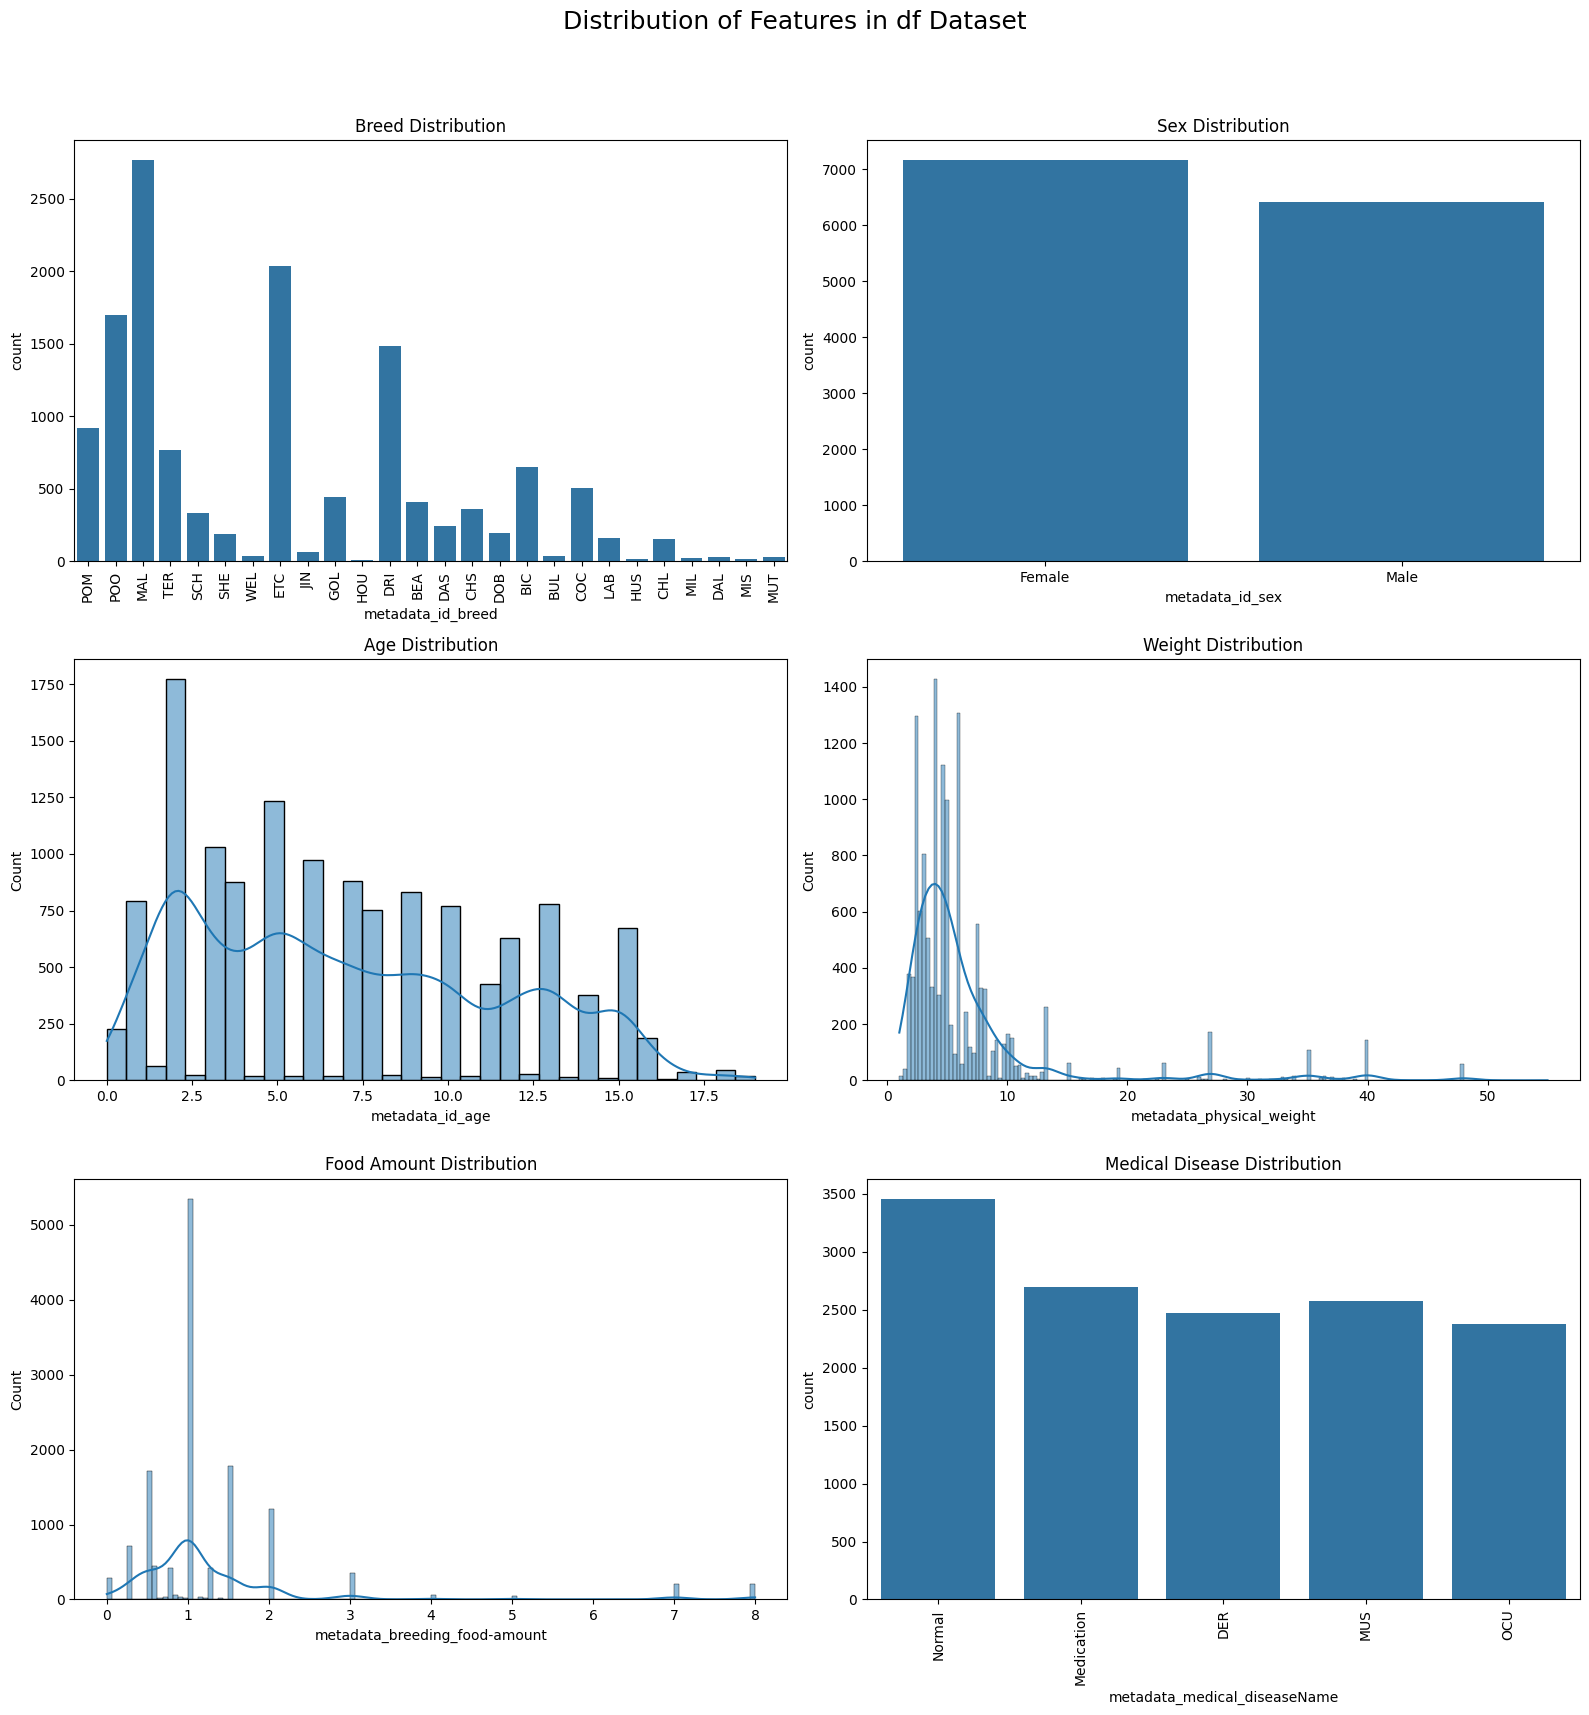

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 필요한 만큼의 서브플롯 생성
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Distribution of Features in df Dataset", fontsize=18)

sns.countplot(data=df, x='metadata_id_breed', ax=axes[0, 0]) # 신동훈 이걸 참아?
axes[0, 0].set_title('Breed Distribution')
axes[0, 0].tick_params(axis='x', rotation=90)

sns.countplot(data=df, x='metadata_id_sex', ax=axes[0, 1])
axes[0, 1].set_title('Sex Distribution')

sns.histplot(df['metadata_id_age'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution')

sns.histplot(df['metadata_physical_weight'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Weight Distribution')

sns.histplot(df['metadata_breeding_food-amount'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Food Amount Distribution')

sns.countplot(data=df, x='metadata_medical_diseaseName', ax=axes[2, 1])
axes[2, 1].set_title('Medical Disease Distribution')
axes[2, 1].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 데이터 EDA

## 질병코드와 다른 열의 비교 시각화

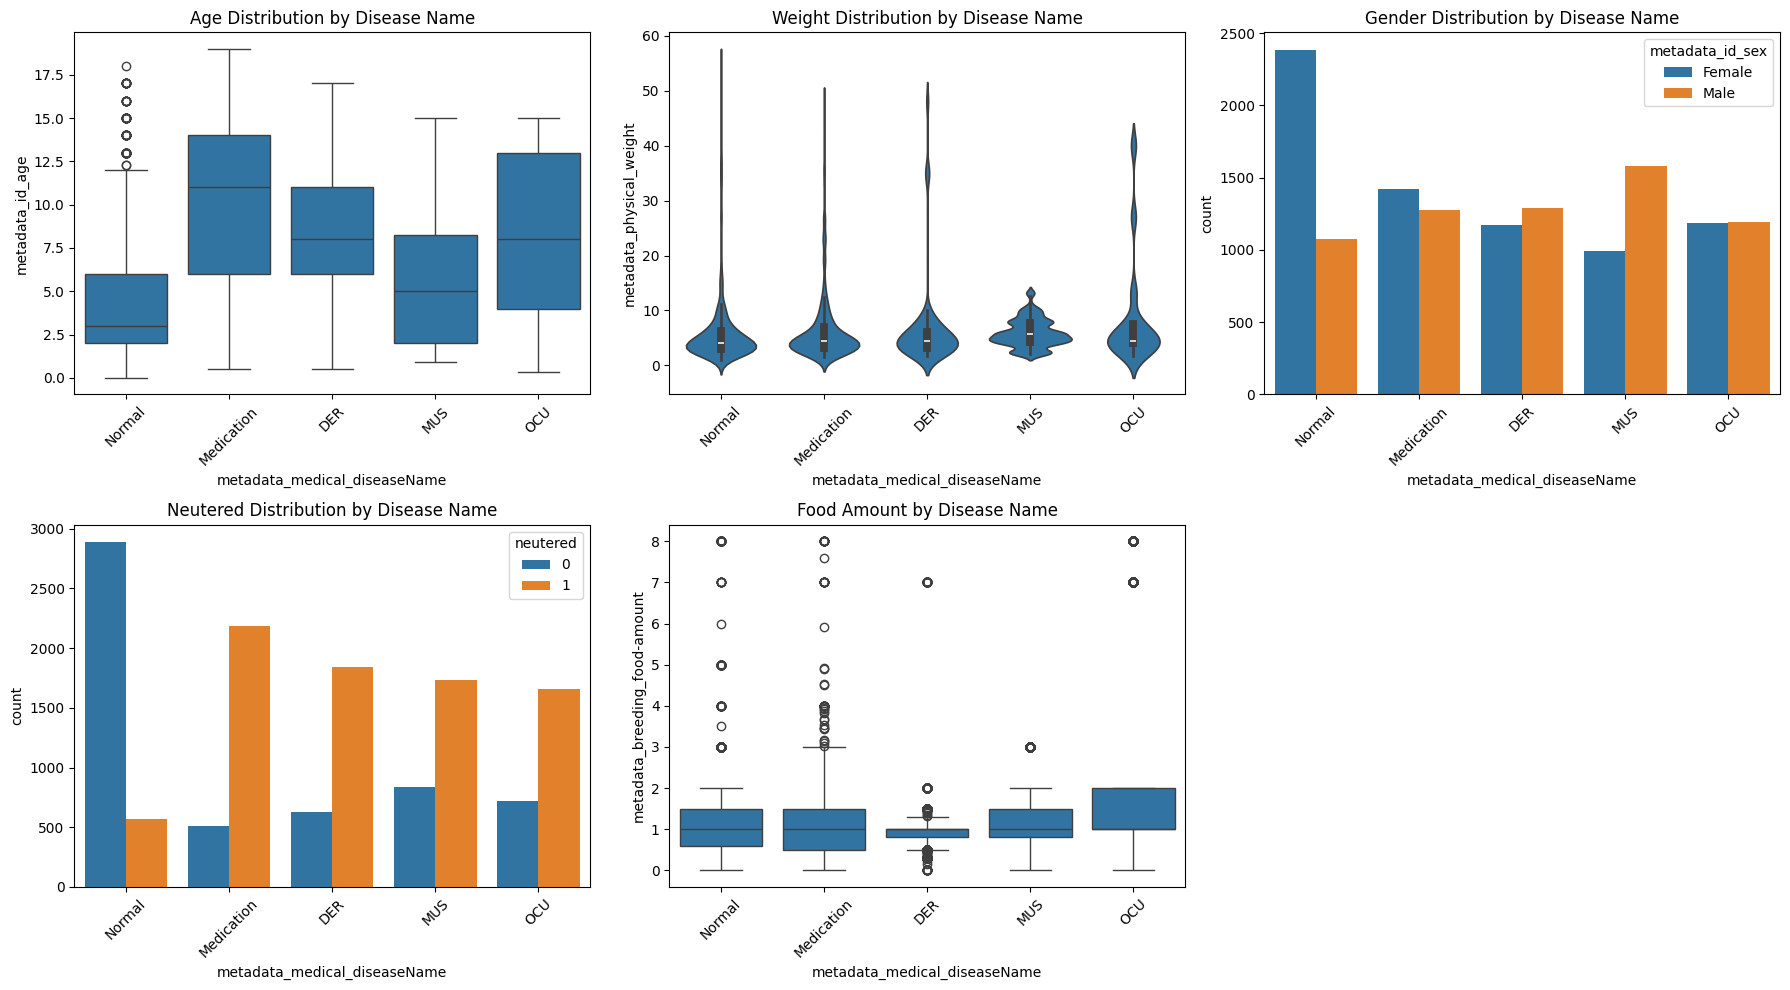

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Figure 크기 설정
plt.figure(figsize=(18, 10))

# 1. metadata_medical_diseaseName과 metadata_id_age의 박스플롯
plt.subplot(2, 3, 1)
sns.boxplot(x='metadata_medical_diseaseName', y='metadata_id_age', data=df)
plt.title('Age Distribution by Disease Name')
plt.xticks(rotation=45)

# 2. metadata_medical_diseaseName과 metadata_physical_weight의 바이올린 플롯
plt.subplot(2, 3, 2)
sns.violinplot(x='metadata_medical_diseaseName', y='metadata_physical_weight', data=df)
plt.title('Weight Distribution by Disease Name')
plt.xticks(rotation=45)

# 3. metadata_medical_diseaseName과 성별(metadata_id_sex) 간의 빈도 막대그래프
plt.subplot(2, 3, 3)
sns.countplot(x='metadata_medical_diseaseName', hue='metadata_id_sex', data=df)
plt.title('Gender Distribution by Disease Name')
plt.xticks(rotation=45)

# 4. metadata_medical_diseaseName과 neutered(중성화 여부) 간의 빈도 막대그래프
plt.subplot(2, 3, 4)
sns.countplot(x='metadata_medical_diseaseName', hue='neutered', data=df)
plt.title('Neutered Distribution by Disease Name')
plt.xticks(rotation=45)

# 5. metadata_medical_diseaseName과 metadata_breeding_food-amount 간의 박스플롯
plt.subplot(2, 3, 5)
sns.boxplot(x='metadata_medical_diseaseName', y='metadata_breeding_food-amount', data=df)
plt.title('Food Amount by Disease Name')
plt.xticks(rotation=45)

# 레이아웃 조정
plt.tight_layout()
plt.show()

## 각 변수별 질병의 유무와 유의미한 관계를 확인하기 위한 통계분석

- 수치형

In [ ]:
import pandas as pd
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# 새로운 열 'disease_status' 추가: 'Normal' 또는 'Disease'로 구분
df['disease_status'] = df['metadata_medical_diseaseName'].apply(lambda x: 'Normal' if x == 'Normal' else 'Disease')

# 그룹화
groups = ['Normal', 'Disease']
numeric_columns = ['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']

# 각 그룹의 데이터를 나누기
group_data = {group: df[df['disease_status'] == group] for group in groups}

# 정규성 검정과 통계 분석
for col in numeric_columns:
    # 각 그룹의 정규성 검정
    group_shapiro = {group: shapiro(group_data[group][col])[1] for group in groups}

    # 두 그룹 간 비교
    if all(p > 0.05 for p in group_shapiro.values()):  # 두 그룹 모두 정규성을 따른다면
        t_stat, p_value = ttest_ind(group_data['Normal'][col], group_data['Disease'][col])
        test_result = "T-test"
    else:  # 정규성을 따르지 않으면
        u_stat, p_value = mannwhitneyu(group_data['Normal'][col], group_data['Disease'][col])
        test_result = "Mann-Whitney U"

    # 출력
    print(f"Column: {col}")
    print(f"Shapiro-Wilk p-values: {group_shapiro}")
    print(f"Test: {test_result}")
    print(f"Statistic: {t_stat if test_result == 'T-test' else u_stat}, p-value: {p_value}")
    print("-" * 50)

Column: metadata_id_age
Shapiro-Wilk p-values: {'Normal': 2.310073066122794e-47, 'Disease': 7.79567339814868e-46}
Test: Mann-Whitney U
Statistic: 8598683.0, p-value: 0.0
--------------------------------------------------
Column: metadata_physical_weight
Shapiro-Wilk p-values: {'Normal': 4.918901872361826e-69, 'Disease': 4.2761599880390116e-95}
Test: Mann-Whitney U
Statistic: 15177622.0, p-value: 2.7234403705753276e-31
--------------------------------------------------
Column: metadata_breeding_food-amount
Shapiro-Wilk p-values: {'Normal': 1.507959063751679e-67, 'Disease': 8.57117049144119e-95}
Test: Mann-Whitney U
Statistic: 17586091.5, p-value: 0.6190821492072041
--------------------------------------------------


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10113.
  res = hypotest_fun_out(*samples, **kwds)


# 1. metadata_id_age (나이):
- Shapiro-Wilk p-value (정규성 검정): Normal과 Disease 모두 p-value가 매우 낮습니다(둘 다 0에 가까운 값). 이는 두 그룹 모두 정규분포를 따르지 않음을 의미합니다.
- 검정 방법: 정규성을 따르지 않으므로 Mann-Whitney U 검정이 사용되었습니다.
검정 통계량: U = 8,598,683, p-value = 0.0
- p-value가 0에 가까운 매우 작은 값이므로, 두 그룹 간 나이의 분포에 유의미한 차이가 있음을 나타냅니다.

# 2. metadata_physical_weight (몸무게):
- Shapiro-Wilk p-value (정규성 검정): Normal과 Disease 그룹 모두 p-value가 매우 낮습니다(둘 다 0에 가까운 값). 이는 두 그룹 모두 정규분포를 따르지 않음을 의미합니다.
- 검정 방법: 정규성을 따르지 않으므로 Mann-Whitney U 검정이 사용되었습니다.
- 검정 통계량: U = 15,177,622, p-value = 2.72e-31
- p-value가 매우 작은 값으로, 두 그룹 간 몸무게의 분포 차이가 유의미함을 알 수 있습니다.

# 3. metadata_breeding_food-amount (식사량):
- Shapiro-Wilk p-value (정규성 검정): Normal과 Disease 그룹 모두 p-value가 매우 낮습니다(둘 다 0에 가까운 값). 이는 두 그룹 모두 정규분포를 따르지 않음을 의미합니다.
- 검정 방법: 정규성을 따르지 않으므로 Mann-Whitney U 검정이 사용되었습니다.
- 검정 통계량: U = 17,586,091.5, p-value = 0.619
- p-value가 0.619로 매우 크기 때문에, 두 그룹 간 식사량의 분포에는 유의미한 차이가 없음을 나타냅니다.

## 결론:
- **metadata_id_age**와 **metadata_physical_weight**는 두 그룹 간 유의미한 차이가 있는 것으로 나타났습니다(p-value < 0.05).
- 반면에 **metadata_breeding_food-amount**는 두 그룹 간 차이가 없는 것으로 나타났습니다(p-value = 0.619).

- 범주형

분석 변수: metadata_id_breed vs metadata_medical_diseaseName

[교차표]
metadata_medical_diseaseName  DER  MUS  Medication  Normal  OCU
metadata_id_breed                                              
BEA                             0  253          23     136    0
BIC                            42    0          34     574    0
BUL                             0    0          33       5    0
CHL                             0    0           2     150    0
CHS                             0  311          22      26    0
COC                            54  218         196      39    0
DAL                             0    4           5      20    0
DAS                            25   90         109      20    0
DOB                            13    6          28       8  138
DRI                           505  106         263      65  547
ETC                           660  331         492     205  350
GOL                            97    0          56      22  271
HOU                             0    0  

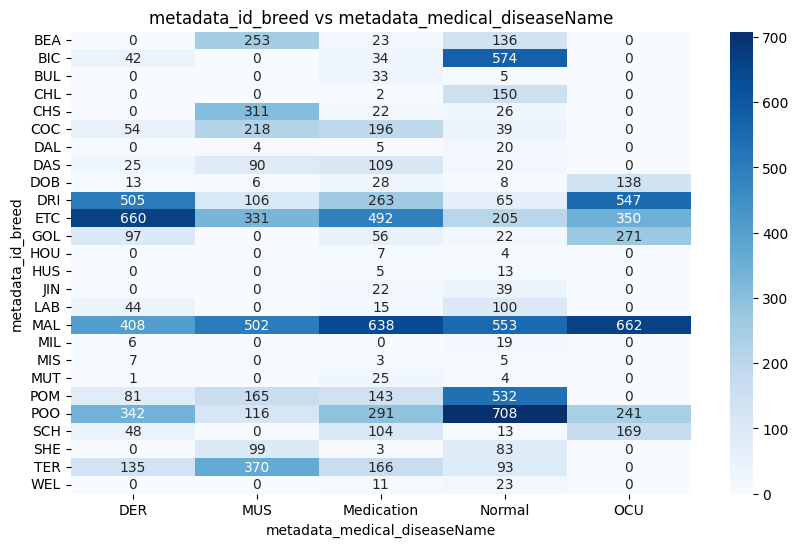

분석 변수: metadata_id_sex vs metadata_medical_diseaseName

[교차표]
metadata_medical_diseaseName   DER   MUS  Medication  Normal   OCU
metadata_id_sex                                                   
Female                        1175   994        1420    2386  1186
Male                          1293  1577        1276    1073  1192

[카이제곱 검정]
Chi-Square Statistic: 604.35
P-value: 0.00000

[Cramér's V]
Cramér's V: 0.21


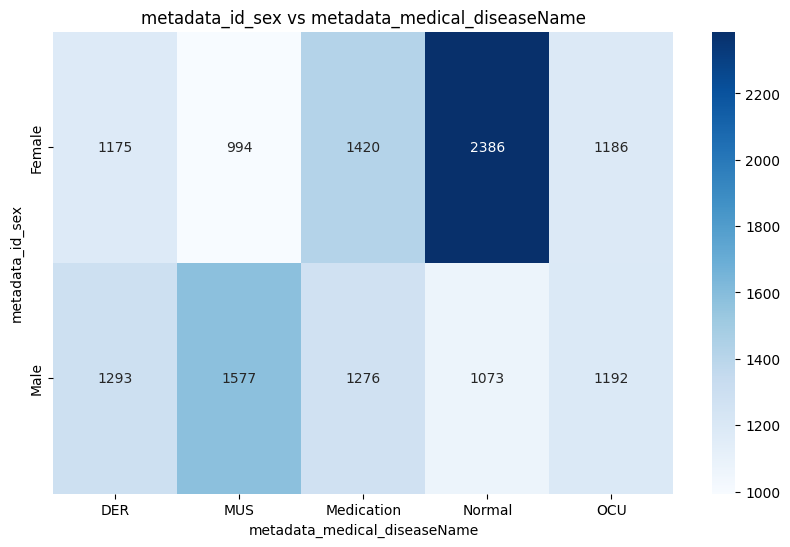

분석 변수: neutered vs metadata_medical_diseaseName

[교차표]
metadata_medical_diseaseName   DER   MUS  Medication  Normal   OCU
neutered                                                          
0                              625   839         507    2889   723
1                             1843  1732        2189     570  1655

[카이제곱 검정]
Chi-Square Statistic: 3566.19
P-value: 0.00000

[Cramér's V]
Cramér's V: 0.51


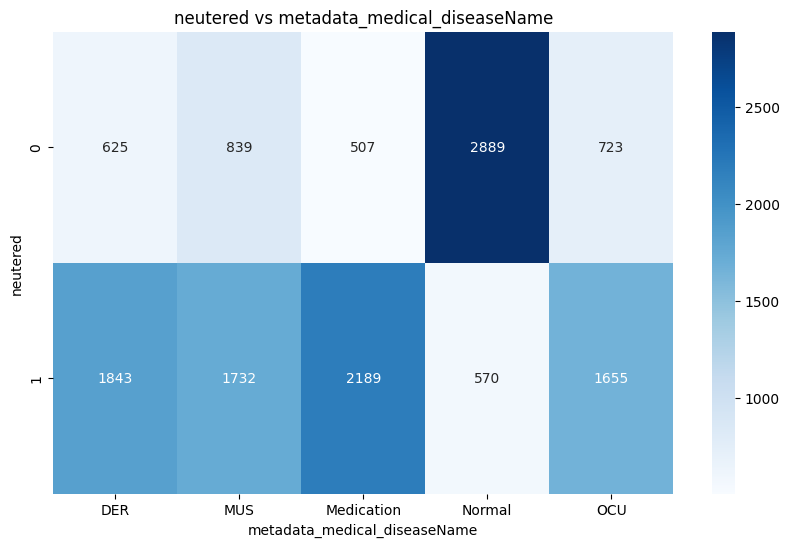


[분석 결과 요약]
            Variable         Chi2        P-value  Cramér's V
0  metadata_id_breed  9235.965574   0.000000e+00    0.412467
1    metadata_id_sex   604.350338  1.772904e-129    0.211019
2           neutered  3566.190334   0.000000e+00    0.512602


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터프레임에서 범주형 컬럼만 추출
categorical_columns = ['metadata_id_breed', 'metadata_id_sex', 'neutered']

# 결과를 저장할 리스트
results = []

# 카이제곱 검정, 교차표 분석, Cramér's V를 각 변수에 대해 실행
for col in categorical_columns:
    print(f"분석 변수: {col} vs metadata_medical_diseaseName")

    # 1. 교차표 생성
    crosstab = pd.crosstab(df[col], df['metadata_medical_diseaseName'])
    print("\n[교차표]")
    print(crosstab)

    # 2. 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print("\n[카이제곱 검정]")
    print(f"Chi-Square Statistic: {chi2:.2f}")
    print(f"P-value: {p:.5f}")

    # 3. Cramér의 V 계산
    n = crosstab.sum().sum()  # 전체 관측치 수
    cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
    print("\n[Cramér's V]")
    print(f"Cramér's V: {cramers_v:.2f}")

    # 결과 저장
    results.append({
        "Variable": col,
        "Chi2": chi2,
        "P-value": p,
        "Cramér's V": cramers_v
    })

    # 4. 교차표 시각화
    plt.figure(figsize=(10, 6))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{col} vs metadata_medical_diseaseName")
    plt.ylabel(col)
    plt.xlabel('metadata_medical_diseaseName')
    plt.show()

# 결과 요약 출력
results_df = pd.DataFrame(results)
print("\n[분석 결과 요약]")
print(results_df)

# 카이제곱 통계량과 크래머V(Cramér's V) 분석 결과 요약

## metadata_id_breed vs metadata_medical_diseaseName
- Chi-Square Statistic: 9235.97
- P-value: 0.00000 (통계적으로 유의미함)
- Cramér's V: 0.41 (중간 정도의 연관성)
- 해석: 강아지의 품종(metadata_id_breed)은 질병 유형(metadata_medical_diseaseName)과 중간 정도의 연관성을 보임. 특정 품종이 특정 질병 유형과 더 관련이 있을 가능성이 있음.

## metadata_id_sex vs metadata_medical_diseaseName
- Chi-Square Statistic: 604.35
- P-value: 0.00000 (통계적으로 유의미함)
- Cramér's V: 0.21 (약한 연관성)
- 해석: 강아지의 성별(metadata_id_sex)은 질병 유형과 약한 연관성을 가짐. 성별이 질병 발생 유형에 미치는 영향은 제한적일 수 있음.


## neutered vs metadata_medical_diseaseName
- Chi-Square Statistic: 3566.19
- P-value: 0.00000 (통계적으로 유의미함)
- Cramér's V: 0.51 (강한 연관성)
- 해석: 중성화 여부(neutered)는 질병 유형과 강한 연관성을 보임. 중성화 상태가 특정 질병 발생 여부에 중요한 요인일 가능성이 높음.

## 전체적인 결론
- 품종(metadata_id_breed)과 중성화 여부(neutered)는 강아지의 질병 유형(metadata_medical_diseaseName)에 중요한 영향을 미치는 변수로 나타남.
- 성별(metadata_id_sex)의 영향은 상대적으로 낮지만, 질병 유형과의 유의미한 연관성을 가지는 것으로 분석됨.
- 향후 추가 분석에서는 품종과 중성화 여부를 중심으로 질병 유형 예측 또는 예방 전략 수립에 초점을 맞출 필요가 있음.

# 각 열별로 어떤 식으로 영향을 미칠까?
  - 로지스틱 회귀 분석으로 알아보자

In [ ]:
df.drop(columns=['disease_status'], inplace=True)

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# 데이터프레임 복사
df_copy = df.copy()

# 'metadata_medical_diseaseName'에 대한 직접적인 매핑 딕셔너리 설정
disease_mapping = {
    'DER': 0,
    'MUS': 1,
    'Medication': 2,
    'Normal': 3,
    'OCU': 4
}

# 'metadata_medical_diseaseName' 열에 대해 매핑 적용
df_copy['metadata_medical_diseaseName'] = df_copy['metadata_medical_diseaseName'].replace(disease_mapping)

# 'metadata_medical_diseaseName'을 범주형 변수로 설정하고 기준 클래스를 'Normal'로 지정
df_copy['metadata_medical_diseaseName'] = pd.Categorical(df_copy['metadata_medical_diseaseName'], categories=[3, 0, 1, 2, 4], ordered=False)

# Label Encoding
le = LabelEncoder()
df_copy['metadata_id_breed'] = le.fit_transform(df_copy['metadata_id_breed'])
df_copy['metadata_id_sex'] = le.fit_transform(df_copy['metadata_id_sex'])

# 독립 변수(X)와 종속 변수(y) 분리
X = df_copy.drop(['metadata_medical_diseaseName'], axis=1)
y = df_copy['metadata_medical_diseaseName']

# 상수항 추가
X = sm.add_constant(X)

# 다항 로지스틱 회귀 모델 생성 및 학습
mnlogit_model = sm.MNLogit(y, X)
result = mnlogit_model.fit()

# 결과 출력
print(result.summary())

<ipython-input-11-7325291b65d0>:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['metadata_medical_diseaseName'] = df_copy['metadata_medical_diseaseName'].replace(disease_mapping)


Optimization terminated successfully.
         Current function value: 1.330557
         Iterations 6
                               MNLogit Regression Results                               
Dep. Variable:     metadata_medical_diseaseName   No. Observations:                13572
Model:                                  MNLogit   Df Residuals:                    13544
Method:                                     MLE   Df Model:                           24
Date:                          Wed, 20 Nov 2024   Pseudo R-squ.:                  0.1683
Time:                                  09:16:22   Log-Likelihood:                -18058.
converged:                                 True   LL-Null:                       -21712.
Covariance Type:                      nonrobust   LLR p-value:                     0.000
metadata_medical_diseaseName=0       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

# 로지스틱 회귀 분석 결과

# 1. metadata_medical_diseaseName=0 (DER)
- metadata_id_age (나이): 나이가 한 살 증가할 때, DER 질병에 걸릴 확률이 약간 증가합니다(계수 0.2345, p-value < 0.05).
- metadata_id_breed (품종): 품종의 영향을 나타내는 변수로, 계수는 -0.0069로, 품종에 따라 DER 질병 확률에 큰 영향을 미치지 않습니다( p-value > 0.05).
- metadata_id_sex (성별): 성별이 남성일 때 DER 질병에 걸릴 확률이 증가합니다(계수 0.8362, p-value < 0.05).
- neutered (중성화 여부): 중성화된 강아지가 DER 질병에 걸릴 확률이 크게 증가합니다(계수 2.1772, p-value < 0.05).
- metadata_physical_weight (체중): 체중은 DER 질병에 큰 영향을 미치지 않습니다(계수 0.0076, p-value > 0.05).
- metadata_breeding_food-amount (먹이량): 먹이량이 많을수록 DER 질병에 걸릴 확률이 낮아집니다(계수 -0.2063, p-value < 0.05).

# 2. metadata_medical_diseaseName=1 (MUS)
- metadata_id_age (나이): 나이가 증가할수록 MUS 질병에 걸릴 확률이 증가합니다(계수 0.0693, p-value < 0.05).
- metadata_id_breed (품종): 품종에 따른 영향을 미치는 변수로, 계수 -0.0267이므로 품종이 MUS 질병 확률에 중요한 영향을 미칩니다(계수 p-value < 0.05).
- metadata_id_sex (성별): 성별이 남성일 때 MUS 질병에 걸릴 확률이 크게 증가합니다(계수 1.0424, p-value < 0.05).
- neutered (중성화 여부): 중성화된 강아지가 MUS 질병에 걸릴 확률이 증가합니다(계수 2.1985, p-value < 0.05).
- metadata_physical_weight (체중): 체중이 많을수록 MUS 질병에 걸릴 확률이 감소합니다(계수 -0.0493, p-value < 0.05).
- metadata_breeding_food-amount (먹이량): 먹이량이 많을수록 MUS 질병에 걸릴 확률이 약간 증가하는 경향이 있습니다(계수 0.0810, p-value = 0.056).

# 3. metadata_medical_diseaseName=2 (Medication)
- metadata_id_age (나이): 나이가 증가할수록 Medication 질병에 걸릴 확률이 크게 증가합니다(계수 0.3275, p-value < 0.05).
- metadata_id_breed (품종): 품종은 Medication 질병에 거의 영향을 미치지 않습니다(계수 -0.0036, p-value > 0.05).
- metadata_id_sex (성별): 성별이 남성일 때 Medication 질병에 걸릴 확률이 증가합니다(계수 0.6545, p-value < 0.05).
- neutered (중성화 여부): 중성화된 강아지가 Medication 질병에 걸릴 확률이 크게 증가합니다(계수 2.5034, p-value < 0.05).
- metadata_physical_weight (체중): 체중이 많을수록 Medication 질병에 걸릴 확률이 감소합니다(계수 -0.0148, p-value < 0.05).
- metadata_breeding_food-amount (먹이량): 먹이량이 많을수록 Medication 질병에 걸릴 확률이 약간 증가하는 경향이 있습니다(계수 0.0608, p-value > 0.05).

# 4. metadata_medical_diseaseName=4 (OCU)
- metadata_id_age (나이): 나이가 증가할수록 OCU 질병에 걸릴 확률이 증가합니다(계수 0.2490, p-value < 0.05).
- metadata_id_breed (품종): 품종은 OCU 질병에 걸릴 확률에 중요한 영향을 미칩니다(계수 -0.0177, p-value < 0.05).
- metadata_id_sex (성별): 성별이 남성일 때 OCU 질병에 걸릴 확률이 증가합니다(계수 0.5152, p-value < 0.05).
- neutered (중성화 여부): 중성화된 강아지가 OCU 질병에 걸릴 확률이 증가합니다(계수 2.1637, p-value < 0.05).
- metadata_physical_weight (체중): 체중이 많을수록 OCU 질병에 걸릴 확률이 감소합니다(계수 -0.0919, p-value < 0.05).
- metadata_breeding_food-amount (먹이량): 먹이량이 많을수록 OCU 질병에 걸릴 확률이 크게 증가합니다(계수 0.7611, p-value < 0.05).

# 군집 분석을 통한 특징 확인
  - K-프로토타입스

In [ ]:
!pip install kmodes

- pca

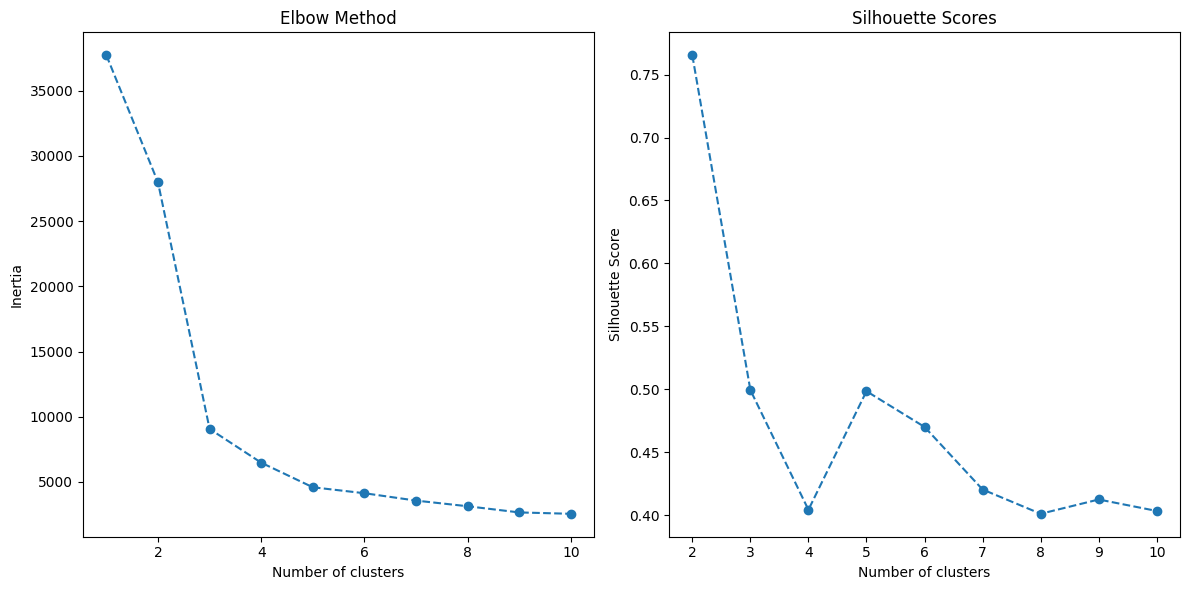

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 원본 데이터프레임을 건드리지 않도록 복사본 생성
df_copy = df.copy()

# 1. 레이블 인코딩 (Label Encoding)
label_encoder = LabelEncoder()

# 범주형 변수에 대해 레이블 인코딩 적용
df_copy['metadata_id_breed'] = label_encoder.fit_transform(df_copy['metadata_id_breed'])
df_copy['metadata_id_sex'] = label_encoder.fit_transform(df_copy['metadata_id_sex'])
df_copy['metadata_medical_diseaseName'] = label_encoder.fit_transform(df_copy['metadata_medical_diseaseName'])

# 2. 수치형 데이터만 선택
numeric_data = df_copy[['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']]

# 3. 데이터 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# 4. PCA 수행
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 5. 엘보우 메서드
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_result)
    inertia.append(kmeans.inertia_)

# 6. 실루엣 계수
silhouette_scores = []
for k in range(2, 11):  # 실루엣 계수는 최소 2개 이상의 클러스터가 필요
    kmeans = KMeans(n_clusters=k)
    cluster_labels = kmeans.fit_predict(pca_result)
    silhouette_avg = silhouette_score(pca_result, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# 시각화: 엘보우 메서드
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

# 시각화: 실루엣 계수
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from kmodes.kprototypes import KPrototypes

kdata = df.copy()

# 범주형 변수 인덱스 지정
categorical_columns = ['metadata_id_breed', 'metadata_id_sex', 'neutered', 'metadata_medical_diseaseName']

# K-프로토타입스를 사용할 수 있도록 범주형 데이터와 수치형 데이터를 나누기
categorical_data = kdata[categorical_columns].apply(lambda x: x.astype('category'))
numerical_data = kdata.drop(categorical_columns, axis=1)

# 범주형 데이터와 수치형 데이터를 모두 포함하는 데이터셋으로 변환
categorical_data_encoded = categorical_data.apply(lambda x: x.cat.codes)

# 수치형 데이터와 범주형 데이터 결합
final_data = pd.concat([numerical_data, categorical_data_encoded], axis=1)

# K-프로토타입스 모델 생성 및 군집화
kproto = KPrototypes(n_clusters=3, init='Cao', verbose=2)
clusters = kproto.fit_predict(final_data, categorical=[1, 2, 3, 6])  # 범주형 데이터 인덱스

# 결과 출력
kdata['Cluster'] = clusters
print(kdata)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 1627, ncost: 72526.69860600993
Run: 1, iteration: 2/100, moves: 8, ncost: 72526.5991817352
Run: 1, iteration: 3/100, moves: 0, ncost: 72526.5991817352
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 992, ncost: 75827.29234891935
Run: 2, iteration: 2/100, moves: 755, ncost: 73391.09680217975
Run: 2, iteration: 3/100, moves: 645, ncost: 72526.66511160393
Run: 2, iteration: 4/100, moves: 5, ncost: 72526.59779482895
Run: 2, iteration: 5/100, moves: 0, ncost: 72526.59779482895
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 2220, ncost: 76327.92284520973
Run: 3, iteration: 2/100, moves: 1032, ncost: 73421.06155878365
Run:

## 각 클러스터별 수치형 통계량 확인

- Cluster 0: 이 클러스터는 나이가 많고 체중이 고르게 분포된 강아지들이 많으며, 먹이 양은 상대적으로 적은 편입니다.
- Cluster 1: 어린 강아지들이 많고, 체중 차이가 매우 크며 먹이 양은 더 많은 경향을 보입니다.
- Cluster 2: 나이가 중간인 강아지들이 많고, 체중은 중간 정도이며 먹이 양은 적당한 수준으로 보입니다.

In [ ]:
# 각 클러스터별 수치형 변수에 대한 통계량 계산
cluster_stats = kdata.groupby('Cluster').agg({
    'metadata_id_age': ['mean', 'std', 'median'],
    'metadata_physical_weight': ['mean', 'std', 'median'],
    'metadata_breeding_food-amount': ['mean', 'std', 'median'],
})

print(cluster_stats)

        metadata_id_age                  metadata_physical_weight            \
                   mean       std median                     mean       std   
Cluster                                                                       
0             13.396074  1.679818   13.0                 6.088398  6.207406   
1              2.882988  1.447184    3.0                 6.974241  7.791484   
2              7.890918  1.433760    8.0                 6.716570  6.754930   

               metadata_breeding_food-amount                   
        median                          mean       std median  
Cluster                                                        
0          4.8                      0.906252  0.656515    1.0  
1          4.4                      1.573186  1.553436    1.0  
2          4.8                      1.222185  1.068607    1.0  


## 2. 범주형 변수의 빈도 분포 확인 종합적 해석
- Cluster 0: 이 클러스터는 나이가 많고 다양한 품종이 포함되어 있으며, 중성화된 강아지들이 많고 질병이 있는 강아지가 많이 포함된 군집입니다.
- Cluster 1: 나이가 어린 강아지들이 많고, 중성화되지 않은 강아지들이 많습니다. 이 클러스터는 건강한 강아지들이 많고, Normal 상태의 강아지가 대부분입니다.
- Cluster 2: 나이가 중간 정도인 강아지들이 포함되며, 중성화된 강아지들이 많습니다. 이 클러스터는 DER, MUS 질병을 가진 강아지가 많고, 일부 Medication을 받은 강아지도 포함됩니다.

In [ ]:
# 각 클러스터별 범주형 변수의 빈도 수 확인
for col in categorical_columns:
    print(f"Cluster-wise distribution for {col}:")
    print(kdata.groupby('Cluster')[col].value_counts())
    print()

Cluster-wise distribution for metadata_id_breed:
Cluster  metadata_id_breed
0        MAL                  681
         DRI                  675
         ETC                  573
         COC                  383
         POO                  249
                             ... 
2        DOB                    7
         HUS                    7
         BUL                    1
         HOU                    1
         MIS                    1
Name: count, Length: 75, dtype: int64

Cluster-wise distribution for metadata_id_sex:
Cluster  metadata_id_sex
0        Female             1782
         Male               1460
1        Female             3136
         Male               2910
2        Female             2243
         Male               2041
Name: count, dtype: int64

Cluster-wise distribution for neutered:
Cluster  neutered
0        1           2564
         0            678
1        0           3653
         1           2393
2        1           3032
         0           1252


## 3. 클러스터별로 특징적인 범주형 변수 확인 종합 해석
- Cluster 0은 **약물 치료(Medication)**와 눈 질환(OCU), **피부 질환(DER)**을 가진 강아지들이 많고, Normal 상태의 강아지는 상대적으로 적습니다.
- Cluster 1은 Normal 상태의 강아지가 가장 많고, **근육 및 골격 질환(MUS)**이 두 번째로 많습니다. 이 군집은 건강한 강아지가 많은 군집입니다.
- Cluster 2는 **피부 질환(DER)**과 **근육 및 골격 질환(MUS)**을 가진 강아지가 많고, **약물 치료(Medication)**을 받는 강아지들도 포함되어 있습니다.

In [ ]:
# 각 클러스터별로 'metadata_medical_diseaseName'의 분포 확인
disease_distribution = kdata.groupby('Cluster')['metadata_medical_diseaseName'].value_counts(normalize=True)
print(disease_distribution)

Cluster  metadata_medical_diseaseName
0        Medication                      0.420419
         OCU                             0.227020
         DER                             0.209130
         MUS                             0.083899
         Normal                          0.059531
1        Normal                          0.423751
         MUS                             0.232385
         OCU                             0.186735
         Medication                      0.083857
         DER                             0.073272
2        DER                             0.314426
         MUS                             0.208683
         Medication                      0.192810
         Normal                          0.164332
         OCU                             0.119748
Name: proportion, dtype: float64


- AVOAV분석

In [ ]:
import pandas as pd
from scipy import stats

# ANOVA 분석을 위한 수치형 변수 리스트
numerical_columns = ['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']

# 각 수치형 변수에 대해 군집 간 차이 분석 (One-way ANOVA)
for column in numerical_columns:
    print(f"ANOVA for {column}:")

    # 군집별로 데이터를 나누기
    groups = [kdata[kdata['Cluster'] == cluster][column] for cluster in kdata['Cluster'].unique()]

    # ANOVA 분석
    f_statistic, p_value = stats.f_oneway(*groups)

    # 결과 출력
    print(f"F-statistic: {f_statistic}, P-value: {p_value}")
    if p_value < 0.05:
        print(f"결과: 군집 간에 {column}에 유의미한 차이가 있습니다.\n")
    else:
        print(f"결과: 군집 간에 {column}에 유의미한 차이가 없습니다.\n")

ANOVA for metadata_id_age:
F-statistic: 52861.628312557004, P-value: 0.0
결과: 군집 간에 metadata_id_age에 유의미한 차이가 있습니다.

ANOVA for metadata_physical_weight:
F-statistic: 16.4243961268792, P-value: 7.509232457503938e-08
결과: 군집 간에 metadata_physical_weight에 유의미한 차이가 있습니다.

ANOVA for metadata_breeding_food-amount:
F-statistic: 318.3906023228691, P-value: 7.4339689936726e-136
결과: 군집 간에 metadata_breeding_food-amount에 유의미한 차이가 있습니다.



# 예측 모델링을 통한 예측 성능 및 변수 중요도 확인

# 데이터 전처리

- 파이프라인 구축

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

df_reg = df.copy()

# 레이블 인코딩을 위한 함수 정의 (BaseEstimator와 TransformerMixin 상속)
class CustomLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = LabelEncoder()

    def fit(self, X, y=None):
        # X를 numpy 배열로 변환 후 ravel() 호출
        self.encoder.fit(X.to_numpy().ravel())
        return self

    def transform(self, X):
        # 변환 시에도 numpy 배열로 변환 후 ravel() 호출
        return self.encoder.transform(X.to_numpy().ravel()).reshape(-1, 1)

    def fit_transform(self, X, y=None):
        # fit_transform 시에도 numpy 배열로 변환 후 ravel() 호출
        return self.encoder.fit_transform(X.to_numpy().ravel()).reshape(-1, 1)

# 수치형 변수 스케일링을 위한 파이프라인 구성
numeric_features = ['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 범주형 변수 레이블 인코딩을 위한 파이프라인 구성
categorical_features = ['metadata_id_breed', 'metadata_id_sex', 'neutered', 'metadata_medical_diseaseName']
categorical_transformers = [
    ('encoder_breed', CustomLabelEncoder()),
    ('encoder_sex', CustomLabelEncoder()),
    ('encoder_disease', CustomLabelEncoder()),
    ('encoder_neutered', CustomLabelEncoder())
]

# ColumnTransformer를 사용하여 수치형과 범주형 컬럼을 각각 처리
# 범주형 컬럼을 각기 개별적으로 처리할 수 있도록 하여, 컬럼별로 transformer를 나눠줍니다.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('breed', CustomLabelEncoder(), ['metadata_id_breed']),
        ('sex', CustomLabelEncoder(), ['metadata_id_sex']),
        ('disease', CustomLabelEncoder(), ['metadata_medical_diseaseName']),
        ('neutered', CustomLabelEncoder(), ['neutered'])
    ]
)

# 전체 파이프라인 구성
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# 데이터에 전처리 파이프라인 적용
df_processed = pipeline.fit_transform(df_reg)

# 수치형 변수의 컬럼명과 범주형 변수의 컬럼명을 합쳐 새로운 DataFrame 컬럼명 생성
num_columns = numeric_features
cat_columns = ['encoded_metadata_id_breed', 'encoded_metadata_id_sex', 'encoded_metadata_medical_diseaseName', 'neutered']

# 반환되는 데이터가 2D 배열이므로 이를 DataFrame으로 변환
df_processed_df = pd.DataFrame(df_processed, columns=num_columns + cat_columns)

# 결과 출력
print(df_processed_df.head())

   metadata_id_age  metadata_physical_weight  metadata_breeding_food-amount  \
0        -0.668114                 -0.095624                      -0.632856   
1         0.679322                 -0.011411                      -0.238838   
2        -1.341832                 -0.404405                      -0.117601   
3        -1.472085                 -0.657044                      -0.632856   
4         0.454750                 -0.011411                      -0.238838   

   encoded_metadata_id_breed  encoded_metadata_id_sex  \
0                       20.0                      0.0   
1                       21.0                      1.0   
2                       21.0                      1.0   
3                       21.0                      1.0   
4                       21.0                      1.0   

   encoded_metadata_medical_diseaseName  neutered  
0                                   3.0       1.0  
1                                   3.0       1.0  
2                         

- metadata_medical_diseaseName열의 인코딩 전 값들 매핑 결과

In [ ]:
# CustomLabelEncoder를 이용해 metadata_medical_diseaseName 열을 인코딩
encoder_disease = CustomLabelEncoder()
encoded_disease = encoder_disease.fit_transform(df_reg['metadata_medical_diseaseName'])

# 매핑 결과 확인
mapping = {original: encoded for original, encoded in zip(encoder_disease.encoder.classes_, range(len(encoder_disease.encoder.classes_)))}

print("인코딩 매핑 관계:")
for original, encoded in mapping.items():
    print(f"{encoded}: {original}")

인코딩 매핑 관계:
0: DER
1: MUS
2: Medication
3: Normal
4: OCU


- 데이터 샘플링

In [ ]:
from sklearn.model_selection import train_test_split

# 데이터를 훈련 세트와 테스트 세트로 분할
X = df_processed_df.drop('encoded_metadata_medical_diseaseName', axis=1)
y = df_processed_df['encoded_metadata_medical_diseaseName']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 학습

- RandomForestClassifier 모델

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# y_test를 One-Hot Encoding (다중 클래스 ROC 계산용)
classes = np.unique(y_train)  # 클래스 목록
n_classes = len(classes)  # 클래스 개수
y_test_bin = label_binarize(y_test, classes=classes)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# 랜덤 포레스트 분류기 생성
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, )

# 훈련 데이터로 모델 학습
rf_classifier.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = rf_classifier.predict(X_test)

accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Accuracy: 0.90
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.94      0.88       494
         1.0       0.91      0.93      0.92       514
         2.0       0.88      0.74      0.80       539
         3.0       0.96      0.90      0.93       692
         4.0       0.90      1.00      0.95       476

    accuracy                           0.90      2715
   macro avg       0.90      0.90      0.90      2715
weighted avg       0.90      0.90      0.90      2715

Confusion Matrix:
 [[465  14   6   0   9]
 [ 28 479   0   1   6]
 [ 57  24 399  26  33]
 [  7  10  50 622   3]
 [  0   0   0   0 476]]
Precision: 0.90
Recall: 0.90
F1 Score: 0.90
Matthews Correlation Coefficient: 0.87
Threat Score: 2.70


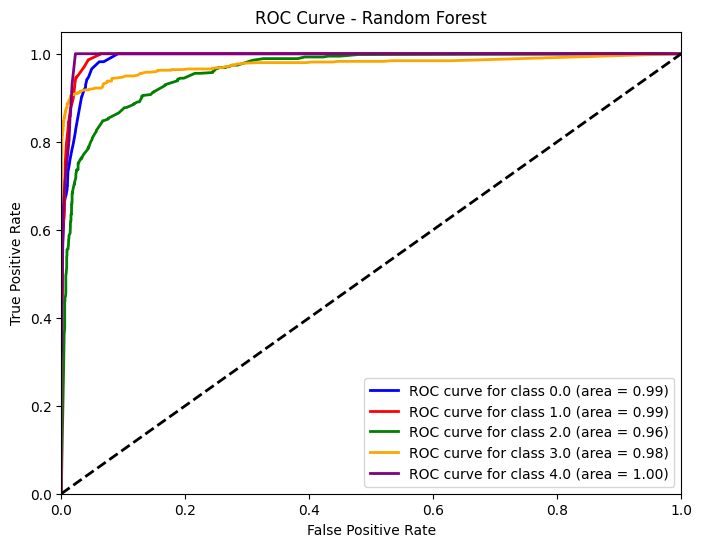

In [ ]:
# 예측 확률 계산
y_score_rf = rf_classifier.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

- XGBClassifier 모델

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# XGBoost 분류기 생성
xgb_classifier = xgb.XGBClassifier(n_estimators=100, random_state=42)

# 훈련 데이터로 모델 학습
xgb_classifier.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = xgb_classifier.predict(X_test)

# 모델 성능 출력
accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Accuracy: 0.90
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.94      0.88       494
         1.0       0.91      0.93      0.92       514
         2.0       0.87      0.75      0.80       539
         3.0       0.97      0.88      0.92       692
         4.0       0.90      1.00      0.95       476

    accuracy                           0.90      2715
   macro avg       0.89      0.90      0.90      2715
weighted avg       0.90      0.90      0.90      2715

Confusion Matrix:
 [[465  14   6   0   9]
 [ 28 479   0   1   6]
 [ 57  24 404  20  34]
 [  9  12  56 612   3]
 [  0   0   0   0 476]]
Precision: 0.90
Recall: 0.90
F1 Score: 0.90
Matthews Correlation Coefficient: 0.87
Threat Score: 2.69


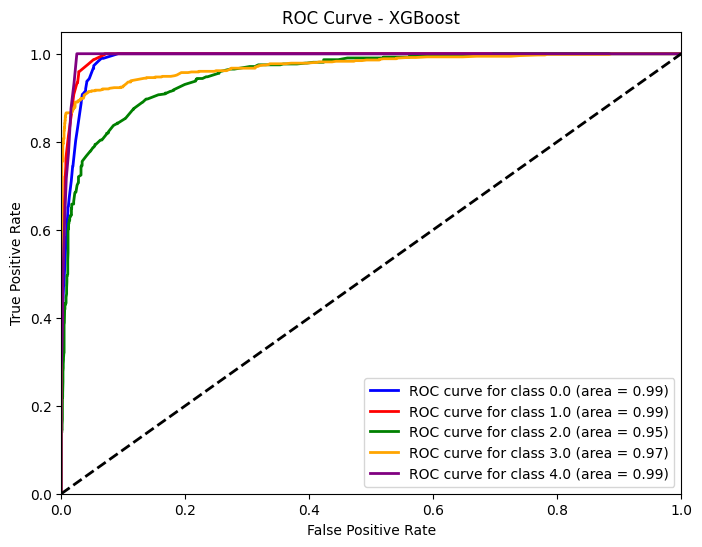

In [ ]:
# 예측 확률 계산
y_score_xgb = xgb_classifier.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.show()

- SVC(서포트 벡터 머신)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 서포트 벡터 머신 모델 생성
svm_model = SVC(kernel='linear', decision_function_shape='ovr')  # 'ovr'은 One-vs-Rest 방식

# 훈련 데이터로 모델 학습
svm_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred_svm = svm_model.predict(X_test)

# 성능 평가
accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Accuracy: 0.90
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.94      0.88       494
         1.0       0.91      0.93      0.92       514
         2.0       0.87      0.75      0.80       539
         3.0       0.97      0.88      0.92       692
         4.0       0.90      1.00      0.95       476

    accuracy                           0.90      2715
   macro avg       0.89      0.90      0.90      2715
weighted avg       0.90      0.90      0.90      2715

Confusion Matrix:
 [[465  14   6   0   9]
 [ 28 479   0   1   6]
 [ 57  24 404  20  34]
 [  9  12  56 612   3]
 [  0   0   0   0 476]]
Precision: 0.90
Recall: 0.90
F1 Score: 0.90
Matthews Correlation Coefficient: 0.87
Threat Score: 2.69


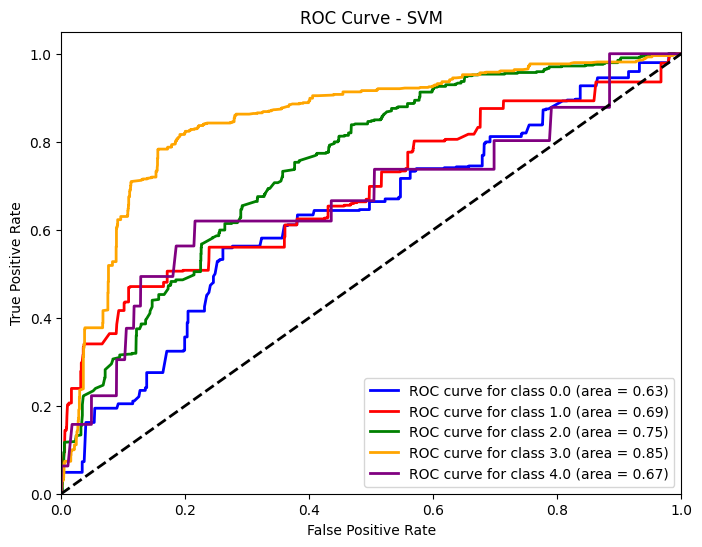

In [ ]:
# 점수 계산 (decision_function)
y_score_svm = svm_model.decision_function(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc="lower right")
plt.show()

- LightGBM 모델

In [ ]:
pip install dask[dataframe]

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 4.4 MB/s eta 0:00:00


In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# LightGBM 모델 생성
lgbm_model = lgb.LGBMClassifier(objective='multiclass', num_class=5, force_row_wise=True)

# 훈련 데이터로 모델 학습
lgbm_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred_lgbm = lgbm_model.predict(X_test)

# 성능 평가
accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Total Bins 678
[LightGBM] [Info] Number of data points in the train set: 10857, number of used features: 6
[LightGBM] [Info] Start training from score -1.704748
[LightGBM] [Info] Start training from score -1.663561
[LightGBM] [Info] Start training from score -1.616092
[LightGBM] [Info] Start training from score -1.367046
[LightGBM] [Info] Start training from score -1.741904
Accuracy: 0.90
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.94      0.88       494
         1.0       0.91      0.93      0.92       514
         2.0       0.87      0.75      0.80       539
         3.0       0.97      0.88      0.92       692
         4.0       0.90      1.00      0.95       476

    accuracy                           0.90      2715
   macro avg       0.89      0.90      0.90      2715
weighted avg       0.90      0.90      0.90      2715

Confusion Matrix:
 [[465  14   6   0   9]
 [ 28 479   0   1   6]
 [ 57  24 40

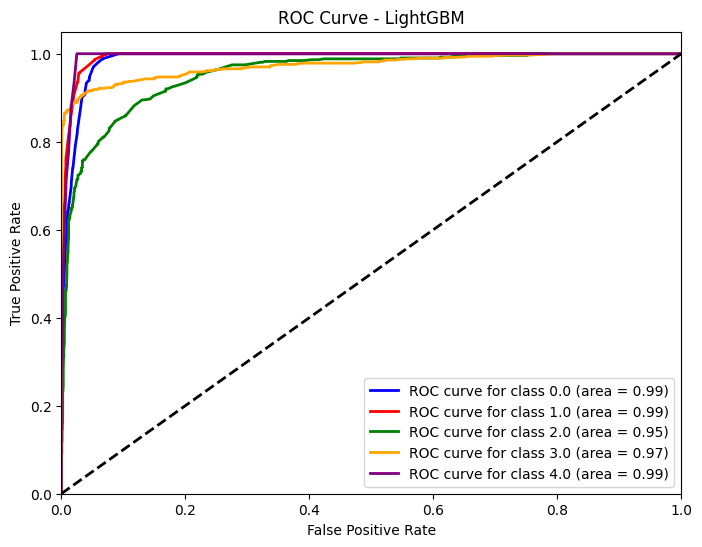

In [ ]:
# 예측 확률 계산
y_score_lgbm = lgbm_model.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_lgbm[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend(loc="lower right")
plt.show()

# 하이퍼파리미터 튜닝(그리드서치)

In [ ]:
X_test.columns, X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2715 entries, 749 to 13469
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   metadata_id_age                2715 non-null   float64
 1   metadata_physical_weight       2715 non-null   float64
 2   metadata_breeding_food-amount  2715 non-null   float64
 3   encoded_metadata_id_breed      2715 non-null   float64
 4   encoded_metadata_id_sex        2715 non-null   float64
 5   neutered                       2715 non-null   float64
dtypes: float64(6)
memory usage: 148.5 KB


(Index(['metadata_id_age', 'metadata_physical_weight',
        'metadata_breeding_food-amount', 'encoded_metadata_id_breed',
        'encoded_metadata_id_sex', 'neutered'],
       dtype='object'),
 None)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 랜덤 포레스트 분류기 생성
rf_classifier = RandomForestClassifier(random_state=42)

# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [50, 100, 150, 200],  # 트리 개수
    'max_depth': [None, 10, 20, 30],  # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10],  # 분할을 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],  # 리프 노드에 있어야 하는 최소 샘플 수
    'max_features': ['auto', 'sqrt', 'log2'],  # 각 트리에서 고려할 특성의 수
    'bootstrap': [True, False]  # 부트스트래핑 여부
}

# 그리드 서치 설정
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, n_jobs=1, verbose=2, scoring='accuracy')

# 훈련 데이터로 하이퍼파라미터 튜닝 수행
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("Best Hyperparameters:", grid_search.best_params_)

# 최적의 모델로 예측
best_rf_classifier = grid_search.best_estimator_
y_pred = best_rf_classifier.predict(X_test)

# 성능 평가
accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1440 fits failed out of a total of 4320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1440 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/u

Best Hyperparameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 0.90
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.93      0.88       476
         1.0       0.90      0.94      0.92       541
         2.0       0.88      0.76      0.81       515
         3.0       0.97      0.89      0.93       700
         4.0       0.90      1.00      0.95       483

    accuracy                           0.90      2715
   macro avg       0.90      0.90      0.90      2715
weighted avg       0.90      0.90      0.90      2715

Confusion Matrix:
 [[445  16  10   0   5]
 [ 27 506   0   2   6]
 [ 50  25 389  14  37]
 [ 11  16  43 622   8]
 [  0   0   0   0 483]]
Precision: 0.90
Recall: 0.90
F1 Score: 0.90


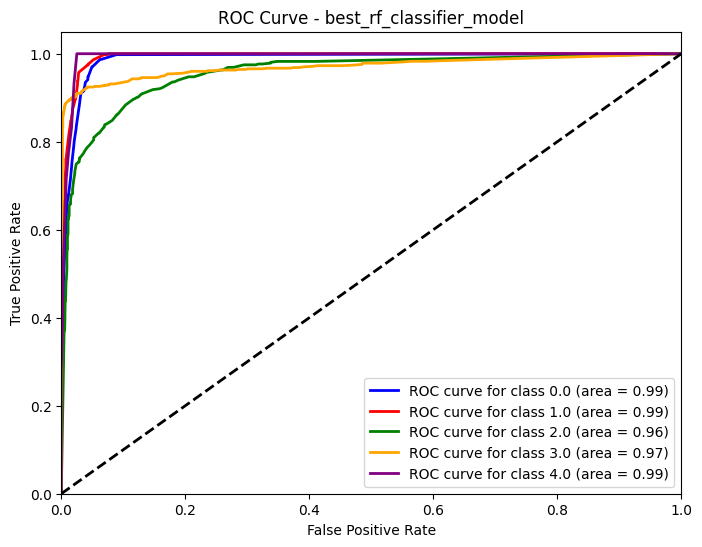

In [ ]:
# 예측 확률 계산
y_score_best = best_rf_classifier.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_best
  [:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - best_rf_classifier_model')
plt.legend(loc="lower right")
plt.show()

- 모델 저장 및 확인

In [ ]:
import pickle

# 그리드 서치에서 최적의 모델을 가져옴
best_rf_classifier = grid_search.best_estimator_

# 학습된 모델을 Pickle을 사용해 저장
with open('best_rf_classifier.pkl', 'wb') as f:
    pickle.dump(best_rf_classifier, f)

print("모델이 'best_rf_classifier.pkl'로 저장되었습니다.")

모델이 'best_rf_classifier.pkl'로 저장되었습니다.


In [ ]:
# Pickle을 사용해 저장된 모델 로드
with open('/content/best_rf_classifier.pkl', 'rb') as f:
    loaded_rf_classifier = pickle.load(f)

# 로드된 모델로 예측
y_pred = loaded_rf_classifier.predict(X_test)
print("모델이 성공적으로 불러와졌습니다.")

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

모델이 성공적으로 불러와졌습니다.
Accuracy: 0.90


# 변수 중요도 및 SHAP

In [ ]:
!pip install shap

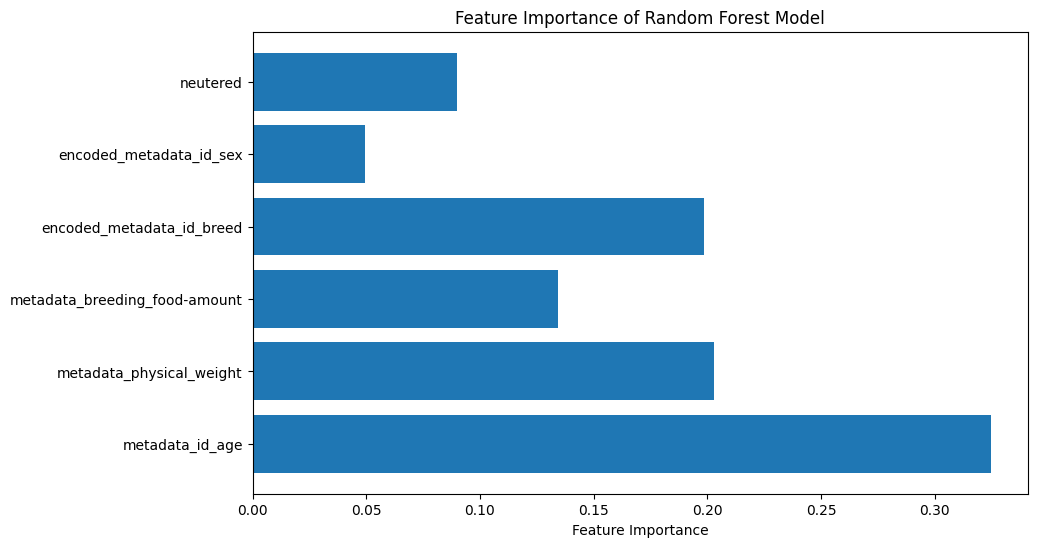

In [ ]:
import matplotlib.pyplot as plt

# 변수 중요도 출력
feature_importances = best_rf_classifier.feature_importances_

# 변수 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance of Random Forest Model')
plt.show()

<Figure size 1600x800 with 0 Axes>

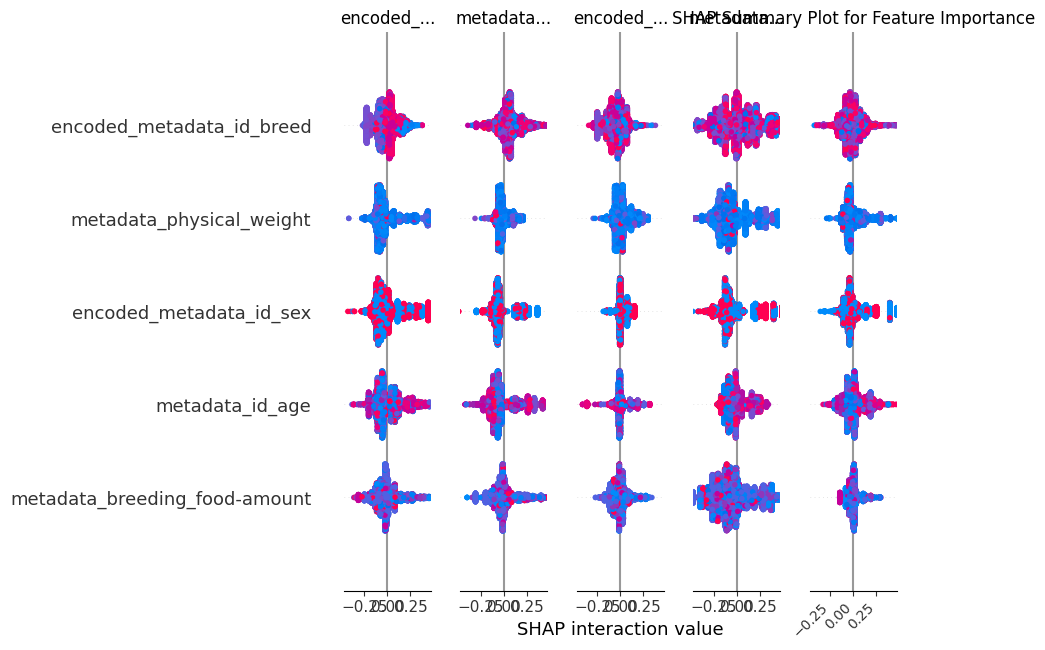

<Figure size 1600x800 with 0 Axes>

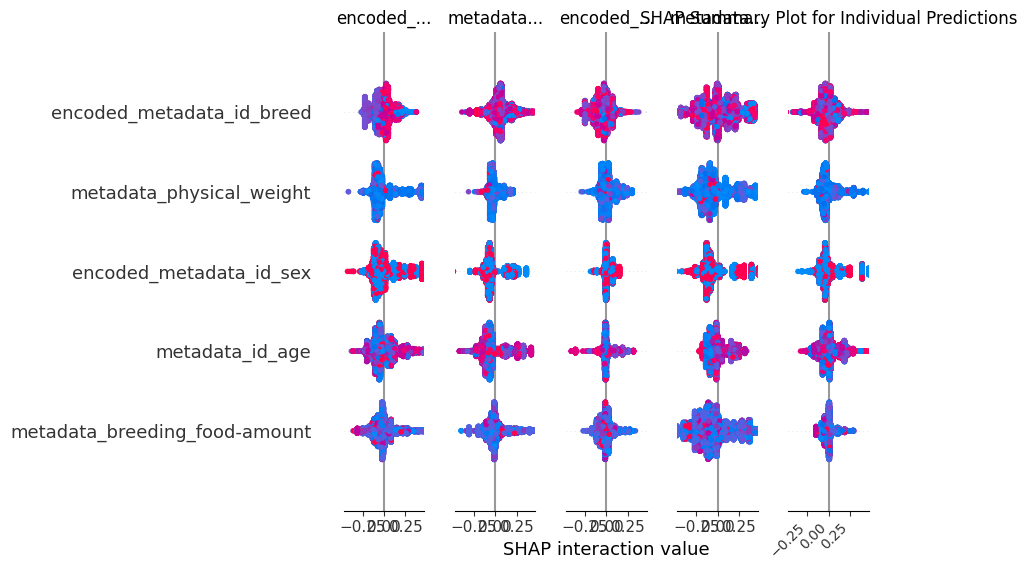

In [ ]:
import shap
import matplotlib.pyplot as plt
from matplotlib import rcParams

# SHAP TreeExplainer 생성
explainer = shap.TreeExplainer(best_rf_classifier)

# SHAP 값을 계산
shap_values = explainer.shap_values(X_train)

# matplotlib 기본 글씨 크기 조정
rcParams.update({'font.size': 10})

# Summary Plot (bar plot)
plt.figure(figsize=(16, 8))  # 더 큰 크기 설정
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title('SHAP Summary Plot for Feature Importance', fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)  # x축 레이블 설정
plt.tight_layout()
plt.show()

# Summary Plot (dot plot)
plt.figure(figsize=(16, 8))  # 더 큰 크기 설정
shap.summary_plot(shap_values, X_train, show=False, max_display=10)
plt.title('SHAP Summary Plot for Individual Predictions', fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)  # x축 레이블 설정
plt.tight_layout()
plt.show()

- 견종, 묘종 리스트랑
질병리스트

In [ ]:
df['metadata_id_breed'].unique()

array(['POM', 'POO', 'MAL', 'TER', 'SCH', 'SHE', 'WEL', 'ETC', 'JIN',
       'GOL', 'HOU', 'DRI', 'BEA', 'DAS', 'CHS', 'DOB', 'BIC', 'BUL',
       'COC', 'LAB', 'HUS', 'CHL', 'MIL', 'DAL', 'MIS', 'MUT'],
      dtype=object)

- POM: 포메라니안
- POO: 푸들
- MAL: 말티즈
- TER: 테리어
- SCH: 슈나우저
- SHE: 쉽독
- WEL: 웰시코기
- ETC: 기타
- JIN: 진도
- GOL: 골든리트리버
- HOU: 하운드
- DRI: 그레이트피레니즈
- BEA: 비글
- DAS: 닥스훈트
- CHS: 치와와
- DOB: 도베르만 핀셔
- BIC: 비숑프리제
- BUL: 불독
- COC: 코커스패니엘
- LAB: 래브라도리트리버
- HUS: 허스키
- CHL: 시추
- MIL: 믹스 장모
- DAL: 닥스훈트 장모
- MIS: 믹스 단모
- MUT: 믹스

In [ ]:
df['metadata_medical_diseaseName'].unique()

array(['Normal', 'Medication', 'DER', 'MUS', 'OCU'], dtype=object)

- Normal: 정상 상태

- Medication: 약물 치료

- DER: Dermatitis(피부염) 또는 Dermatologic disease(피부 질환)

- MUS: Musculoskeletal(근골격계 질환)

- OCU: Ocular(눈과 관련된 질환)